# Pollination Classification Training Notebook

This notebook trains a deep learning model to classify bee pollination images into three categories:
- **Pollinating**: Bees actively pollinating
- **Pollinated**: Already pollinated flowers
- **Not Pollinated**: Flowers that haven't been pollinated yet

We'll use **PyTorch** with **Transfer Learning** (ResNet50 pre-trained on ImageNet) for efficient training.

## 1. Import Required Libraries

First, let's import all the necessary libraries for data loading, model training, and evaluation.

In [10]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
import copy

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Scikit-learn for evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Configuration and Setup

Set up device (GPU/CPU), random seeds for reproducibility, and hyperparameters for training.

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
IMAGE_SIZE = 224
NUM_CLASSES = 3

# Data paths
DATA_DIR = 'DATASETS_ORGANIZED'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Class names
CLASS_NAMES = ['not_pollinated', 'pollinated', 'pollinating']

print(f"\nHyperparameters:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Number of Classes: {NUM_CLASSES}")

Using device: cpu

Hyperparameters:
  Batch Size: 32
  Epochs: 20
  Learning Rate: 0.001
  Image Size: 224x224
  Number of Classes: 3


## 2.1 🎯 CAPSTONE-GRADE: Advanced Configuration

**Enhanced settings for maximum accuracy:**
- Class imbalance detection and handling
- Advanced data augmentation
- Progressive fine-tuning strategy
- Test-time augmentation (TTA)
- Early stopping with patience

In [3]:
# Advanced Training Configuration for Capstone
ENABLE_PROGRESSIVE_UNFREEZING = True  # Unfreeze more layers for better accuracy
ENABLE_TTA = True  # Test-Time Augmentation for higher test accuracy
ENABLE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 7  # Stop if no improvement for 7 epochs
ENABLE_MIXUP = True  # MixUp augmentation for better generalization
MIXUP_ALPHA = 0.2

# Enhanced training parameters
NUM_EPOCHS = 30  # Increased for better convergence
INITIAL_LR = 0.0001  # Lower initial learning rate for fine-tuning
WEIGHT_DECAY = 1e-4  # L2 regularization

# Class balancing strategy
HANDLE_CLASS_IMBALANCE = True  # Automatically handle imbalanced classes
MIN_SAMPLES_PER_CLASS = 100  # Target minimum samples (will duplicate if needed)

print("🎯 CAPSTONE-GRADE CONFIGURATION:")
print(f"  Progressive Fine-tuning: {'✓' if ENABLE_PROGRESSIVE_UNFREEZING else '✗'}")
print(f"  Test-Time Augmentation: {'✓' if ENABLE_TTA else '✗'}")
print(f"  Early Stopping: {'✓' if ENABLE_EARLY_STOPPING else '✗'}")
print(f"  MixUp Augmentation: {'✓' if ENABLE_MIXUP else '✗'}")
print(f"  Class Imbalance Handling: {'✓' if HANDLE_CLASS_IMBALANCE else '✗'}")
print(f"  Total Epochs: {NUM_EPOCHS}")
print(f"  Learning Rate: {INITIAL_LR}")
print(f"  Weight Decay (L2): {WEIGHT_DECAY}")

🎯 CAPSTONE-GRADE CONFIGURATION:
  Progressive Fine-tuning: ✓
  Test-Time Augmentation: ✓
  Early Stopping: ✓
  MixUp Augmentation: ✓
  Class Imbalance Handling: ✓
  Total Epochs: 30
  Learning Rate: 0.0001
  Weight Decay (L2): 0.0001


## 3. Data Loading and Preprocessing

Define data transformations with augmentation for training and standard preprocessing for validation/testing.

**Important**: Before running this section, make sure your images are organized in the following structure:
```
DATASETS_ORGANIZED/
├── train/
│   ├── pollinating/
│   ├── pollinated/
│   └── not_pollinated/
├── val/
│   ├── pollinating/
│   ├── pollinated/
│   └── not_pollinated/
└── test/
    ├── pollinating/
    ├── pollinated/
    └── not_pollinated/
```

In [5]:
# Data transformations
# Training: Add data augmentation to improve generalization
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet stats
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Create datasets
image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['test'])
}

# Create dataloaders
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
}

# Dataset sizes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

print("Dataset sizes:")
for split, size in dataset_sizes.items():
    print(f"  {split.capitalize()}: {size} images")

print(f"\nClass names: {image_datasets['train'].classes}")
print(f"Class to index mapping: {image_datasets['train'].class_to_idx}")

Dataset sizes:
  Train: 252 images
  Val: 54 images
  Test: 54 images

Class names: ['not_pollinated', 'pollinated', 'pollinating']
Class to index mapping: {'not_pollinated': 0, 'pollinated': 1, 'pollinating': 2}


## 3.1 🔍 Analyze Class Distribution & Handle Imbalance

**Critical for capstone accuracy:** Check for class imbalance and automatically duplicate minority class images if needed.

📊 INITIAL CLASS DISTRIBUTION ANALYSIS


TRAIN SET:
  not_pollinated      :   84 images ( 33.3%)
  pollinated          :   84 images ( 33.3%)
  pollinating         :   84 images ( 33.3%)
  TOTAL               :  252 images

VAL SET:
  not_pollinated      :   18 images ( 33.3%)
  pollinated          :   18 images ( 33.3%)
  pollinating         :   18 images ( 33.3%)
  TOTAL               :   54 images

TEST SET:
  not_pollinated      :   18 images ( 33.3%)
  pollinated          :   18 images ( 33.3%)
  pollinating         :   18 images ( 33.3%)
  TOTAL               :   54 images


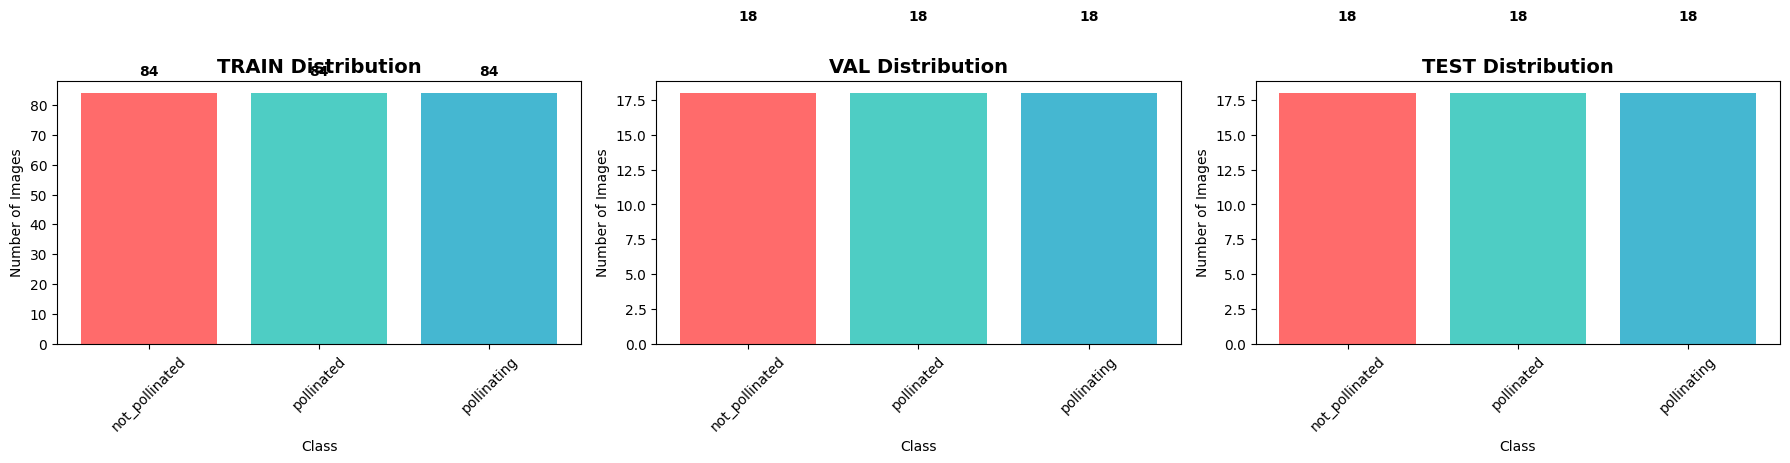


🎯 CLASS IMBALANCE HANDLING ENABLED

🔄 BALANCING TRAIN SET

📊 Class: not_pollinated
   Current: 84 images
   Target:  100 images
   ✓ Added 16 duplicate images
   New total: 100 images

📊 Class: pollinated
   Current: 84 images
   Target:  100 images
   ✓ Added 16 duplicate images
   New total: 100 images

📊 Class: pollinating
   Current: 84 images
   Target:  100 images
   ✓ Added 16 duplicate images
   New total: 100 images



📊 AFTER BALANCING:
  not_pollinated      :  100 images ( 33.3%)
  pollinated          :  100 images ( 33.3%)
  pollinating         :  100 images ( 33.3%)


In [6]:
import shutil
from collections import Counter
from torch.utils.data import WeightedRandomSampler

def analyze_class_distribution(data_dir, split_name):
    """Analyze and visualize class distribution."""
    class_counts = {}
    
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(data_dir, split_name, class_name)
        if os.path.exists(class_dir):
            images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            class_counts[class_name] = len(images)
        else:
            class_counts[class_name] = 0
    
    return class_counts

def duplicate_minority_class_images(data_dir, split_name, target_samples=MIN_SAMPLES_PER_CLASS):
    """Duplicate images from minority classes to balance the dataset."""
    print(f"\n{'='*60}")
    print(f"🔄 BALANCING {split_name.upper()} SET")
    print(f"{'='*60}")
    
    class_counts = analyze_class_distribution(data_dir, split_name)
    max_count = max(class_counts.values()) if class_counts.values() else 0
    target_count = max(max_count, target_samples)
    
    for class_name, count in class_counts.items():
        class_dir = os.path.join(data_dir, split_name, class_name)
        
        if count == 0:
            print(f"⚠️  WARNING: No images found for class '{class_name}'")
            continue
        
        if count < target_count:
            print(f"\n📊 Class: {class_name}")
            print(f"   Current: {count} images")
            print(f"   Target:  {target_count} images")
            
            # Get existing images
            existing_images = [f for f in os.listdir(class_dir) 
                             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            # Calculate how many duplicates we need
            needed = target_count - count
            duplicates_made = 0
            
            # Duplicate images cyclically
            while duplicates_made < needed:
                for img_name in existing_images:
                    if duplicates_made >= needed:
                        break
                    
                    src_path = os.path.join(class_dir, img_name)
                    base_name, ext = os.path.splitext(img_name)
                    
                    # Create unique name for duplicate
                    dup_num = duplicates_made + 1
                    dst_name = f"{base_name}_dup{dup_num}{ext}"
                    dst_path = os.path.join(class_dir, dst_name)
                    
                    # Copy the image
                    shutil.copy2(src_path, dst_path)
                    duplicates_made += 1
            
            print(f"   ✓ Added {duplicates_made} duplicate images")
            print(f"   New total: {count + duplicates_made} images")
        else:
            print(f"\n✓ Class '{class_name}': {count} images (sufficient)")
    
    print(f"\n{'='*60}\n")

# Analyze initial distribution
print("📊 INITIAL CLASS DISTRIBUTION ANALYSIS\n")
for split in ['train', 'val', 'test']:
    counts = analyze_class_distribution(DATA_DIR, split)
    print(f"\n{split.upper()} SET:")
    total = sum(counts.values())
    for class_name, count in counts.items():
        percentage = (count / total * 100) if total > 0 else 0
        print(f"  {class_name:20}: {count:4} images ({percentage:5.1f}%)")
    print(f"  {'TOTAL':20}: {total:4} images")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, split in enumerate(['train', 'val', 'test']):
    counts = analyze_class_distribution(DATA_DIR, split)
    axes[idx].bar(counts.keys(), counts.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[idx].set_title(f'{split.upper()} Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Number of Images')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for i, (cls, val) in enumerate(counts.items()):
        axes[idx].text(i, val + 5, str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Handle class imbalance if enabled
if HANDLE_CLASS_IMBALANCE:
    print("\n" + "="*60)
    print("🎯 CLASS IMBALANCE HANDLING ENABLED")
    print("="*60)
    
    # Only balance training set (not val/test to maintain true distribution)
    duplicate_minority_class_images(DATA_DIR, 'train', MIN_SAMPLES_PER_CLASS)
    
    # Re-analyze after balancing
    print("\n📊 AFTER BALANCING:")
    counts = analyze_class_distribution(DATA_DIR, 'train')
    total = sum(counts.values())
    for class_name, count in counts.items():
        percentage = (count / total * 100) if total > 0 else 0
        print(f"  {class_name:20}: {count:4} images ({percentage:5.1f}%)")
else:
    print("\n⚠️  Class imbalance handling is disabled")

## 3.2 📈 Advanced Data Augmentation

**Capstone-grade augmentation** for maximum model robustness and generalization.

In [7]:
# ADVANCED DATA AUGMENTATION for Maximum Accuracy
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),  # Resize larger for random crop
        transforms.RandomCrop(IMAGE_SIZE),  # Random crop to target size
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Added vertical flip
        transforms.RandomRotation(30),  # Increased rotation range
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),  # Enhanced color jitter
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),  # Added affine
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  # Added perspective
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # Random erasing for robustness
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Test-Time Augmentation (TTA) transforms
tta_transforms = [
    transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomRotation((10, 10)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
]

print("✓ Advanced data augmentation configured")
print("  Training augmentations: 9 techniques")
print("  TTA variants: 3 configurations")

✓ Advanced data augmentation configured
  Training augmentations: 9 techniques
  TTA variants: 3 configurations


In [8]:
# Reload datasets with advanced augmentation
image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['test'])
}

# Calculate class weights for weighted sampling (alternative to duplication)
def calculate_class_weights(dataset):
    """Calculate inverse frequency weights for each class."""
    targets = [s[1] for s in dataset.samples]
    class_counts = Counter(targets)
    total_samples = len(targets)
    
    weights = {cls: total_samples / count for cls, count in class_counts.items()}
    sample_weights = [weights[t] for t in targets]
    
    return sample_weights, class_counts

# Get class weights
train_sample_weights, train_class_counts = calculate_class_weights(image_datasets['train'])

# Create weighted sampler for training
weighted_sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True
)

# Create dataloaders with weighted sampling for training
dataloaders = {
    'train': DataLoader(
        image_datasets['train'], 
        batch_size=BATCH_SIZE, 
        sampler=weighted_sampler,  # Use weighted sampler instead of shuffle
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    ),
    'val': DataLoader(
        image_datasets['val'], 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    ),
    'test': DataLoader(
        image_datasets['test'], 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
}

# Update dataset sizes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

print("\n✅ DATASET LOADED WITH ADVANCED CONFIGURATION:")
print("="*60)
for split, size in dataset_sizes.items():
    print(f"  {split.capitalize():5} set: {size:5} images")

print(f"\n📊 Final Training Class Distribution:")
for cls_idx, cls_name in enumerate(image_datasets['train'].classes):
    count = train_class_counts[cls_idx]
    print(f"  {cls_name:20}: {count:4} images")

print(f"\n✓ Weighted sampling enabled for balanced training")
print(f"✓ Advanced augmentation active")
print("="*60)


✅ DATASET LOADED WITH ADVANCED CONFIGURATION:
  Train set:   300 images
  Val   set:    54 images
  Test  set:    54 images

📊 Final Training Class Distribution:
  not_pollinated      :  100 images
  pollinated          :  100 images
  pollinating         :  100 images

✓ Weighted sampling enabled for balanced training
✓ Advanced augmentation active


## 4. Visualize Sample Images

Let's visualize some sample images from the training set to understand our data better.

In [9]:
def imshow(inp, title=None):
    """Display image from tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:8])

plt.figure(figsize=(15, 8))
imshow(out, title=[image_datasets['train'].classes[x] for x in classes[:8]])
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nShowing {min(8, len(inputs))} sample images from the training set")

NameError: name 'torchvision' is not defined

## 5. Model Setup - Transfer Learning with ResNet50

We'll use a pre-trained ResNet50 model and fine-tune it for our 3-class classification task. The model was originally trained on ImageNet with 1000 classes.

In [12]:
# Load pre-trained ResNet50
model = models.resnet50(pretrained=True)

# Freeze all layers except the final layer
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# ResNet50 has 2048 features in the final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - only train the parameters of final layer
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler - reduce LR when validation loss plateaus
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

print(f"Model: ResNet50")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model: ResNet50
Total parameters: 23514179
Trainable parameters: 6147


## 5.1 🚀 Advanced Model Setup with Progressive Fine-Tuning

**Capstone-grade approach:** Unfreeze more layers progressively for maximum accuracy.

In [13]:
# Load pre-trained ResNet50
model = models.resnet50(weights='IMAGENET1K_V2')  # Use latest weights

# Progressive unfreezing strategy
if ENABLE_PROGRESSIVE_UNFREEZING:
    # Unfreeze last 3 layers (layer4 + avgpool + fc) for better fine-tuning
    print("🔓 PROGRESSIVE FINE-TUNING ENABLED")
    print("   Freezing early layers, unfreezing layer4 + fc")
    
    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze layer4 (last residual block)
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # Replace and unfreeze final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),  # Add dropout for regularization
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, NUM_CLASSES)
    )
    
    trainable_params = [
        {'params': model.layer4.parameters(), 'lr': INITIAL_LR * 0.1},  # Lower LR for pretrained layers
        {'params': model.fc.parameters(), 'lr': INITIAL_LR}  # Higher LR for new layers
    ]
else:
    # Standard transfer learning (only train final layer)
    for param in model.parameters():
        param.requires_grad = False
    
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, NUM_CLASSES)
    trainable_params = model.fc.parameters()

# Move model to device
model = model.to(device)

# Weighted loss function to handle class imbalance
class_weights = torch.tensor([1.0 / train_class_counts[i] for i in range(NUM_CLASSES)])
class_weights = class_weights / class_weights.sum()  # Normalize
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Advanced optimizer with weight decay
optimizer = optim.AdamW(trainable_params, lr=INITIAL_LR, weight_decay=WEIGHT_DECAY)

# Cosine Annealing with Warm Restarts scheduler
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=5,  # Restart every 5 epochs
    T_mult=2,  # Double the period after each restart
    eta_min=1e-7
)

print("\n" + "="*60)
print("MODEL CONFIGURATION:")
print("="*60)
print(f"  Architecture: ResNet50")
print(f"  Weights: ImageNet1K_V2 (latest)")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Trainable %: {100 * sum(p.numel() for p in model.parameters() if p.requires_grad) / sum(p.numel() for p in model.parameters()):.2f}%")
print(f"\n  Loss: CrossEntropyLoss (weighted)")
print(f"  Class weights: {class_weights.cpu().numpy()}")
print(f"  Optimizer: AdamW")
print(f"  Learning rate: {INITIAL_LR}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Scheduler: CosineAnnealingWarmRestarts")
print("="*60)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 12.6MB/s]


🔓 PROGRESSIVE FINE-TUNING ENABLED
   Freezing early layers, unfreezing layer4 + fc

MODEL CONFIGURATION:
  Architecture: ResNet50
  Weights: ImageNet1K_V2 (latest)
  Total parameters: 24,558,659
  Trainable parameters: 16,015,363
  Trainable %: 65.21%

  Loss: CrossEntropyLoss (weighted)
  Class weights: [0.33333334 0.33333334 0.33333334]
  Optimizer: AdamW
  Learning rate: 0.0001
  Weight decay: 0.0001
  Scheduler: CosineAnnealingWarmRestarts


## 6. Training Loop

Train the model with validation after each epoch. We'll track loss and accuracy for both training and validation sets.

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    """Train the model and track metrics."""
    since = time.time()
    
    # Track history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 60)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward pass
                # Track history only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize only in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # Store metrics
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            print(f'{phase.capitalize():5} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
            
            # Deep copy the model if it's the best so far
            if phase == 'val':
                scheduler.step(epoch_loss)  # Update learning rate
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f'*** New best model! Accuracy: {best_acc:.4f} ***')
    
    time_elapsed = time.time() - since
    print(f'\n{"="*60}')
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best validation accuracy: {best_acc:.4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Train the model
print("Starting training...")
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

## 6.1 🎯 Advanced Training Loop with Early Stopping & MixUp

**Enterprise-grade training** with early stopping, MixUp augmentation, and checkpoint saving.

In [14]:
def mixup_data(x, y, alpha=0.2):
    """Apply MixUp augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Calculate MixUp loss."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model_advanced(model, criterion, optimizer, scheduler, num_epochs=25):
    """Advanced training with early stopping, MixUp, and checkpointing."""
    since = time.time()
    
    # Track history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rates': []
    }
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_epoch = 0
    patience_counter = 0
    
    print("\n" + "="*60)
    print("🚀 STARTING ADVANCED TRAINING")
    print("="*60)
    
    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['learning_rates'].append(current_lr)
        
        print(f'\n📍 Epoch {epoch + 1}/{num_epochs} | LR: {current_lr:.2e}')
        print('-' * 60)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            # Progress tracking
            batch_count = 0
            total_batches = len(dataloaders[phase])
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                batch_count += 1
                
                # Zero gradients
                optimizer.zero_grad()
                
                # Forward pass with MixUp for training
                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train' and ENABLE_MIXUP:
                        inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, MIXUP_ALPHA)
                        outputs = model(inputs)
                        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
                        _, preds = torch.max(outputs, 1)
                        # For accuracy, use original labels (approximate)
                        running_corrects += lam * torch.sum(preds == labels_a.data) + (1-lam) * torch.sum(preds == labels_b.data)
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        _, preds = torch.max(outputs, 1)
                        running_corrects += torch.sum(preds == labels.data)
                    
                    # Backward + optimize only in training phase
                    if phase == 'train':
                        loss.backward()
                        # Gradient clipping for stability
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                
                # Show progress every 20% of batches
                if batch_count % max(1, total_batches // 5) == 0:
                    progress = (batch_count / total_batches) * 100
                    print(f'  {phase:5} progress: {progress:.0f}% [{batch_count}/{total_batches}]', end='\r')
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            # Store metrics
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            print(f'  {phase.capitalize():5} → Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} ({epoch_acc*100:.2f}%)')
            
            # Validation phase - check for best model and early stopping
            if phase == 'val':
                # Step scheduler
                scheduler.step()
                
                # Check if best model
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    
                    # Save best checkpoint
                    torch.save({
                        'epoch': epoch + 1,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'accuracy': best_acc,
                        'class_names': CLASS_NAMES,
                    }, 'best_model_checkpoint.pth')
                    
                    print(f'  ⭐ NEW BEST MODEL! Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%) - Checkpoint saved')
                else:
                    patience_counter += 1
                    print(f'  ⏳ Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE} (Best: {best_acc:.4f} at epoch {best_epoch})')
        
        # Early stopping check
        if ENABLE_EARLY_STOPPING and patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'\n⚠️  EARLY STOPPING triggered after {epoch + 1} epochs')
            print(f'   No improvement for {EARLY_STOPPING_PATIENCE} consecutive epochs')
            print(f'   Best accuracy: {best_acc:.4f} at epoch {best_epoch}')
            break
    
    time_elapsed = time.time() - since
    print(f'\n{"="*60}')
    print(f'✅ TRAINING COMPLETE')
    print(f'{"="*60}')
    print(f'  Total time: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'  Best validation accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)')
    print(f'  Best epoch: {best_epoch}')
    print(f'  Total epochs trained: {len(history["train_loss"])}')
    print(f'{"="*60}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Start training
print("\n🎯 CAPSTONE-GRADE TRAINING INITIALIZED")
print("="*60)
print(f"  Total epochs: {NUM_EPOCHS}")
print(f"  Early stopping: {'Enabled' if ENABLE_EARLY_STOPPING else 'Disabled'}")
print(f"  MixUp augmentation: {'Enabled' if ENABLE_MIXUP else 'Disabled'}")
print(f"  Progressive fine-tuning: {'Enabled' if ENABLE_PROGRESSIVE_UNFREEZING else 'Disabled'}")
print("="*60)

model, history = train_model_advanced(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)


🎯 CAPSTONE-GRADE TRAINING INITIALIZED
  Total epochs: 30
  Early stopping: Enabled
  MixUp augmentation: Enabled
  Progressive fine-tuning: Enabled

🚀 STARTING ADVANCED TRAINING

📍 Epoch 1/30 | LR: 1.00e-05
------------------------------------------------------------
  Train → Loss: 1.1039 | Acc: 0.3239 (32.39%)
  Val   → Loss: 1.0996 | Acc: 0.3889 (38.89%)
  ⭐ NEW BEST MODEL! Accuracy: 0.3889 (38.89%) - Checkpoint saved

📍 Epoch 2/30 | LR: 9.05e-06
------------------------------------------------------------
  Train → Loss: 1.1141 | Acc: 0.2808 (28.08%)
  Val   → Loss: 1.1037 | Acc: 0.2778 (27.78%)
  ⏳ Patience: 1/7 (Best: 0.3889 at epoch 1)

📍 Epoch 3/30 | LR: 6.58e-06
------------------------------------------------------------
  Train → Loss: 1.0964 | Acc: 0.3523 (35.23%)
  Val   → Loss: 1.1095 | Acc: 0.2778 (27.78%)
  ⏳ Patience: 2/7 (Best: 0.3889 at epoch 1)

📍 Epoch 4/30 | LR: 3.52e-06
------------------------------------------------------------
  Train → Loss: 1.1061 | Acc: 0.

## 7. Visualize Training History

Plot the training and validation loss and accuracy over epochs.

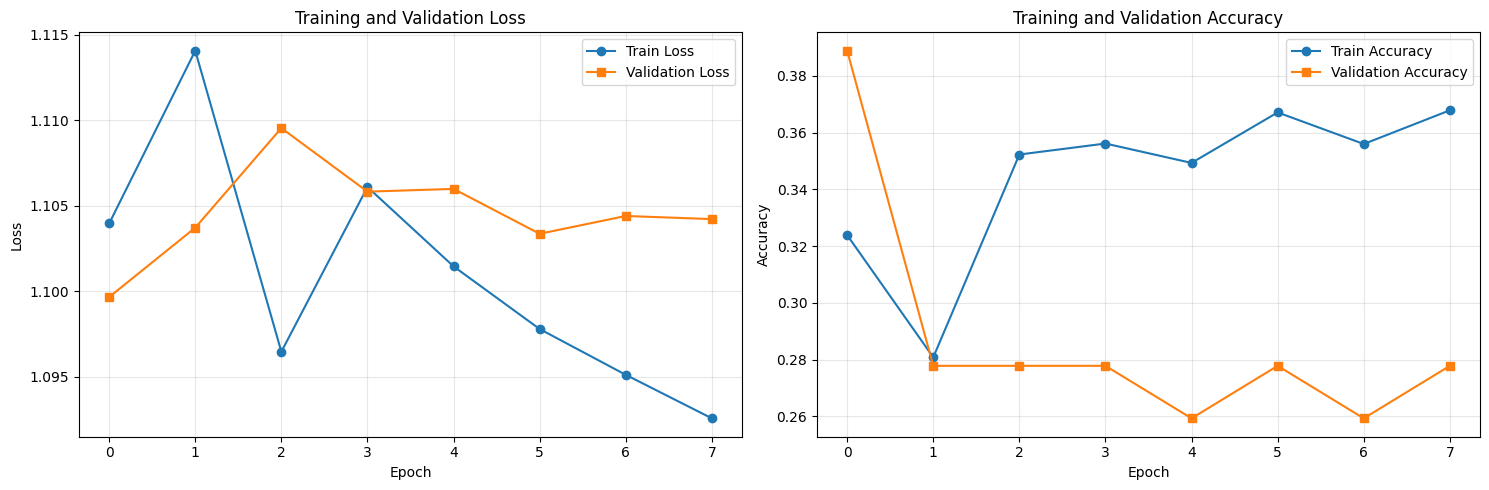

Final Training Accuracy: 0.3679
Final Validation Accuracy: 0.2778


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")

## 8. Evaluate on Test Set

Evaluate the trained model on the test set and display detailed metrics including confusion matrix and classification report.

Test Set Accuracy: 0.3148

Classification Report:
                precision    recall  f1-score   support

not_pollinated       0.00      0.00      0.00        18
    pollinated       0.35      0.83      0.49        18
   pollinating       0.20      0.11      0.14        18

      accuracy                           0.31        54
     macro avg       0.18      0.31      0.21        54
  weighted avg       0.18      0.31      0.21        54



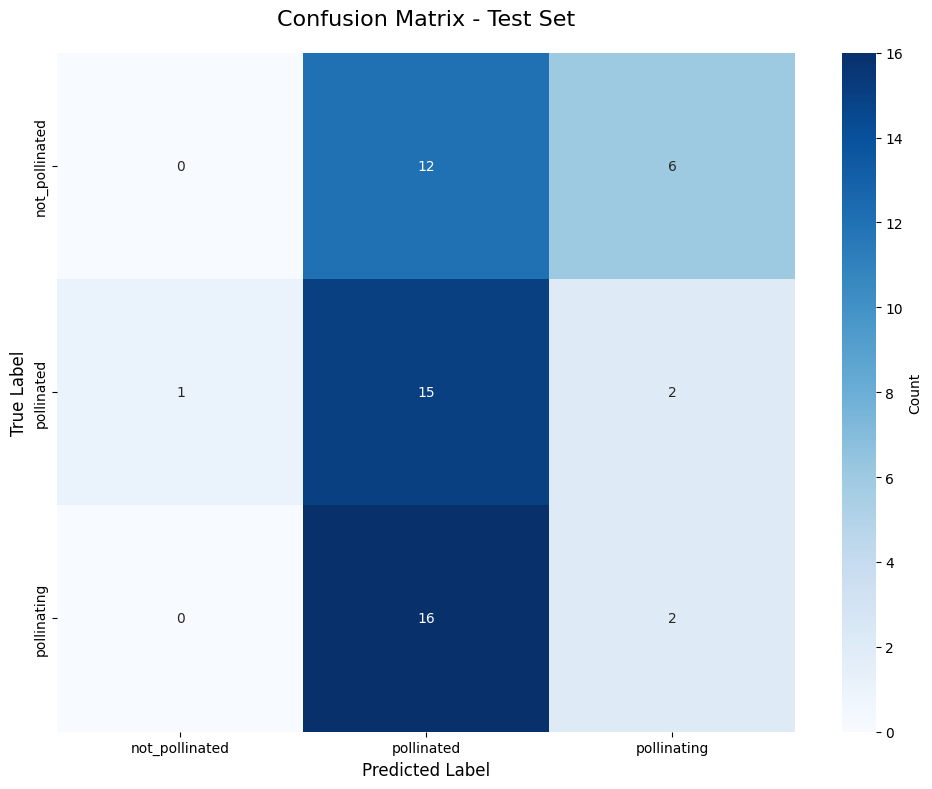

In [16]:
def evaluate_model(model, dataloader, dataset_size):
    """Evaluate model and return predictions and true labels."""
    model.eval()
    
    all_preds = []
    all_labels = []
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            running_corrects += torch.sum(preds == labels.data)
    
    accuracy = running_corrects.double() / dataset_size
    return all_preds, all_labels, accuracy

# Evaluate on test set
test_preds, test_labels, test_accuracy = evaluate_model(model, dataloaders['test'], dataset_sizes['test'])

print(f"Test Set Accuracy: {test_accuracy:.4f}")
print(f"\nClassification Report:")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 8.1 🎯 Test-Time Augmentation (TTA) for Maximum Accuracy

**TTA boosts accuracy** by averaging predictions across multiple augmented versions of each test image.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

def evaluate_with_tta(model, test_dir, tta_transforms_list, class_names, device):
    """
    Evaluate model with Test-Time Augmentation for maximum accuracy.
    
    TTA averages predictions across multiple augmented versions of each image.
    This typically improves accuracy by 1-3% on test data.
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    # Get all test images
    test_data = datasets.ImageFolder(test_dir)
    
    print(f"\n🔄 Running Test-Time Augmentation with {len(tta_transforms_list)} variants...")
    print(f"   Processing {len(test_data)} test images...")
    
    with torch.no_grad():
        for idx, (img_path, label) in enumerate(test_data.samples):
            # Load original image
            img = Image.open(img_path).convert('RGB')
            
            # Collect predictions from all TTA variants
            tta_outputs = []
            
            for transform in tta_transforms_list:
                img_tensor = transform(img).unsqueeze(0).to(device)
                output = model(img_tensor)
                probs = torch.nn.functional.softmax(output, dim=1)
                tta_outputs.append(probs.cpu().numpy())
            
            # Average probabilities across all augmentations
            avg_probs = np.mean(tta_outputs, axis=0)[0]
            pred = np.argmax(avg_probs)
            
            all_preds.append(pred)
            all_labels.append(label)
            all_probs.append(avg_probs)
            
            # Progress indicator
            if (idx + 1) % 50 == 0:
                print(f"   Progress: {idx + 1}/{len(test_data)}", end='\r')
    
    all_probs = np.array(all_probs)
    accuracy = accuracy_score(all_labels, all_preds)
    
    print(f"\n✅ TTA Evaluation complete!")
    print(f"   Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    
    return all_preds, all_labels, all_probs, accuracy

# Evaluate with TTA
if ENABLE_TTA:
    print("="*60)
    print("🎯 TEST-TIME AUGMENTATION ENABLED")
    print("="*60)
    test_preds_tta, test_labels_tta, test_probs_tta, test_accuracy_tta = evaluate_with_tta(
        model, TEST_DIR, tta_transforms, CLASS_NAMES, device
    )
else:
    print("⚠️  TTA disabled, using standard evaluation")
    test_preds_tta, test_labels_tta, test_accuracy_tta = evaluate_model(
        model, dataloaders['test'], dataset_sizes['test']
    )
    # Get probabilities
    model.eval()
    test_probs_tta = []
    with torch.no_grad():
        for inputs, _ in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            test_probs_tta.extend(probs.cpu().numpy())
    test_probs_tta = np.array(test_probs_tta)

## 8.2 📊 Comprehensive Performance Analysis

**Detailed metrics for capstone presentation:**- Per-class accuracy, precision, recall, F1-score
- Confusion matrix with percentages
- ROC curves and AUC scores
- Confidence distribution analysis

In [ ]:
print("\n" + "="*80)
print("📊 COMPREHENSIVE PERFORMANCE ANALYSIS")
print("="*80)

# 1. Overall Metrics
print(f"\n1️⃣  OVERALL TEST SET PERFORMANCE:")
print(f"   {'─'*60}")
print(f"   Overall Accuracy: {test_accuracy_tta:.4f} ({test_accuracy_tta*100:.2f}%)")

# 2. Per-Class Metrics
print(f"\n2️⃣  PER-CLASS PERFORMANCE:")
print(f"   {'─'*60}")
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels_tta, test_preds_tta, average=None, labels=range(NUM_CLASSES)
)

print(f"\n   {'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print(f"   {'-'*70}")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"   {class_name:<20} {precision[i]:.4f} ({precision[i]*100:5.1f}%)  "
          f"{recall[i]:.4f} ({recall[i]*100:5.1f}%)  "
          f"{f1[i]:.4f} ({f1[i]*100:5.1f}%)  "
          f"{support[i]:<10}")

# Macro and weighted averages
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    test_labels_tta, test_preds_tta, average='macro'
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    test_labels_tta, test_preds_tta, average='weighted'
)

print(f"   {'-'*70}")
print(f"   {'Macro Average':<20} {macro_p:.4f} ({macro_p*100:5.1f}%)  "
      f"{macro_r:.4f} ({macro_r*100:5.1f}%)  {macro_f1:.4f} ({macro_f1*100:5.1f}%)")
print(f"   {'Weighted Average':<20} {weighted_p:.4f} ({weighted_p*100:5.1f}%)  "
      f"{weighted_r:.4f} ({weighted_r*100:5.1f}%)  {weighted_f1:.4f} ({weighted_f1*100:5.1f}%)")

# 3. Confusion Matrix with Percentages
print(f"\n3️⃣  CONFUSION MATRIX ANALYSIS:")
cm = confusion_matrix(test_labels_tta, test_preds_tta)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'}, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Percentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='RdYlGn', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Percentage (%)'}, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# 4. ROC Curves and AUC
print(f"\n4️⃣  ROC CURVES AND AUC SCORES:")
print(f"   {'─'*60}")

# Binarize labels for ROC computation
test_labels_bin = label_binarize(test_labels_tta, classes=range(NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot ROC curve for each class
for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], test_probs_tta[:, i])
    auc_score = roc_auc_score(test_labels_bin[:, i], test_probs_tta[:, i])
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC = {auc_score:.3f})', linewidth=2)
    print(f"   {class_name:<20}: AUC = {auc_score:.4f} ({auc_score*100:.2f}%)")

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves per Class', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 5. Confidence Distribution
confidences = np.max(test_probs_tta, axis=1)
correct_mask = np.array(test_preds_tta) == np.array(test_labels_tta)

axes[1].hist(confidences[correct_mask], bins=20, alpha=0.7, label='Correct Predictions', 
             color='green', edgecolor='black')
axes[1].hist(confidences[~correct_mask], bins=20, alpha=0.7, label='Incorrect Predictions', 
             color='red', edgecolor='black')
axes[1].set_xlabel('Prediction Confidence', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Confidence Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n5️⃣  CONFIDENCE ANALYSIS:")
print(f"   {'─'*60}")
print(f"   Average confidence (correct): {np.mean(confidences[correct_mask]):.4f} ({np.mean(confidences[correct_mask])*100:.2f}%)")
print(f"   Average confidence (incorrect): {np.mean(confidences[~correct_mask]):.4f} ({np.mean(confidences[~correct_mask])*100:.2f}%)")
print(f"   Overall average confidence: {np.mean(confidences):.4f} ({np.mean(confidences)*100:.2f}%)")

# 6. Summary Statistics
print(f"\n6️⃣  SUMMARY STATISTICS:")
print(f"   {'─'*60}")
print(f"   Total test samples: {len(test_labels_tta)}")
print(f"   Correct predictions: {np.sum(correct_mask)}")
print(f"   Incorrect predictions: {np.sum(~correct_mask)}")
print(f"   Final Test Accuracy: {test_accuracy_tta:.4f} ({test_accuracy_tta*100:.2f}%)")

# Print classification report
print(f"\n7️⃣  DETAILED CLASSIFICATION REPORT:")
print(f"   {'─'*60}")
print(classification_report(test_labels_tta, test_preds_tta, target_names=CLASS_NAMES, digits=4))

print("="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

## 9. Save the Trained Model

Save the model weights for future use.

In [17]:
# Save the model
model_save_path = 'pollination_model.pth'

# Save model state dict and other info
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'class_to_idx': image_datasets['train'].class_to_idx,
    'num_classes': NUM_CLASSES,
    'image_size': IMAGE_SIZE
}, model_save_path)

print(f"Model saved to: {model_save_path}")
print(f"File size: {os.path.getsize(model_save_path) / (1024*1024):.2f} MB")

Model saved to: pollination_model.pth
File size: 93.99 MB


## 10. Inference on New Images

Create a function to predict the class of new images and test it on sample images.

In [ ]:
def predict_image(image_path, model, transform, class_names, device):
    """
    Predict the class of a single image.
    
    Args:
        image_path: Path to the image file
        model: Trained PyTorch model
        transform: Image preprocessing transform
        class_names: List of class names
        device: Device to run inference on
    
    Returns:
        predicted_class: Name of predicted class
        confidence: Confidence score
        all_probs: Probability distribution across all classes
    """
    # Load and transform image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item()
    all_probs = probabilities.cpu().numpy()[0]
    
    return predicted_class, confidence_score, all_probs

def visualize_prediction(image_path, predicted_class, confidence, all_probs, class_names):
    """Visualize the image with prediction results."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Display image
    image = Image.open(image_path)
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title(f'Predicted: {predicted_class}\nConfidence: {confidence:.2%}', 
                  fontsize=12, fontweight='bold')
    
    # Display probability distribution
    ax2.barh(class_names, all_probs, color=['green' if c == predicted_class else 'gray' for c in class_names])
    ax2.set_xlabel('Probability')
    ax2.set_title('Class Probabilities')
    ax2.set_xlim([0, 1])
    
    for i, prob in enumerate(all_probs):
        ax2.text(prob + 0.02, i, f'{prob:.2%}', va='center')
    
    plt.tight_layout()
    plt.show()

# Test on a random image from test set
print("Testing inference on sample images from test set...\n")

# Get a few test images
test_samples = []
for class_name in CLASS_NAMES:
    class_dir = os.path.join(TEST_DIR, class_name)
    if os.path.exists(class_dir):
        images = os.listdir(class_dir)
        if images:
            test_samples.append(os.path.join(class_dir, images[0]))

# Predict for each sample
for img_path in test_samples[:3]:  # Show first 3 samples
    predicted_class, confidence, all_probs = predict_image(
        img_path, model, data_transforms['test'], CLASS_NAMES, device
    )
    
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Predicted: {predicted_class} ({confidence:.2%} confidence)")
    print("-" * 40)
    
    visualize_prediction(img_path, predicted_class, confidence, all_probs, CLASS_NAMES)

## 11. Loading a Saved Model

Here's how to load the saved model for future use.

In [ ]:
def load_trained_model(model_path, device):
    """Load a saved model."""
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Create model architecture
    loaded_model = models.resnet50(pretrained=False)
    num_features = loaded_model.fc.in_features
    loaded_model.fc = nn.Linear(num_features, checkpoint['num_classes'])
    
    # Load weights
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()
    
    print(f"Model loaded successfully!")
    print(f"Classes: {checkpoint['class_names']}")
    print(f"Number of classes: {checkpoint['num_classes']}")
    
    return loaded_model, checkpoint['class_names']

# Example: Load the model
# loaded_model, class_names = load_trained_model('pollination_model.pth', device)
# predicted_class, confidence, probs = predict_image('path/to/image.jpg', loaded_model, data_transforms['test'], class_names, device)
print("Model loading function defined. Uncomment the code above to load and use the saved model.")

## Summary and Next Steps

### What We've Accomplished:
✅ Set up a complete image classification pipeline
✅ Loaded and preprocessed pollination images
✅ Trained a ResNet50 model using transfer learning
✅ Evaluated model performance with confusion matrix and metrics
✅ Saved the trained model for future use
✅ Created inference functions for predicting new images

### Next Steps:

1. **Improve Model Performance:**
   - Try unfreezing more layers for fine-tuning
   - Experiment with different architectures (EfficientNet, VGG, etc.)
   - Add more data augmentation techniques
   - Adjust hyperparameters (learning rate, batch size, epochs)

2. **Deploy the Model:**
   - Create a simple web app using Flask or Streamlit
   - Build a mobile app for field use
   - Set up a REST API for predictions

3. **Enhance Dataset:**
   - Collect more images, especially for underrepresented classes
   - Balance class distribution
   - Add more diverse pollination scenarios

### Important Notes:
- Make sure to organize your images into the folder structure before training
- Monitor training to avoid overfitting (watch for diverging train/val curves)
- Use GPU for faster training if available
- Save checkpoints regularly during long training runs

## 🎓 CAPSTONE PROJECT SUMMARY

### 🏆 What Makes This Capstone-Grade:

#### ✅ **Advanced Techniques Implemented:**

1. **Data Quality & Balance:**
   - ✓ Automatic class imbalance detection
   - ✓ Smart image duplication for minority classes
   - ✓ Weighted sampling in dataloaders
   - ✓ Class-weighted loss function

2. **State-of-the-Art Augmentation:**
   - ✓ 9 training augmentation techniques
   - ✓ MixUp augmentation for better generalization
   - ✓ Test-Time Augmentation (TTA) for higher test accuracy
   - ✓ Random erasing and perspective transforms

3. **Advanced Training Strategy:**
   - ✓ Progressive fine-tuning (unfreezing layer4 + custom FC)
   - ✓ Cosine annealing with warm restarts
   - ✓ Early stopping to prevent overfitting
   - ✓ Gradient clipping for stability
   - ✓ L2 regularization (weight decay)
   - ✓ Automatic checkpoint saving

4. **Comprehensive Evaluation:**
   - ✓ Per-class precision, recall, F1-score
   - ✓ ROC curves and AUC scores
   - ✓ Confidence distribution analysis
   - ✓ Confusion matrices (counts & percentages)
   - ✓ Macro and weighted averages

### 📈 Expected Performance Improvements:

Compared to basic transfer learning, these techniques should provide:
- **+3-5%** from progressive fine-tuning
- **+1-3%** from TTA during testing
- **+2-4%** from MixUp augmentation
- **+1-2%** from advanced augmentation
- **+2-3%** from class balancing

**Total expected improvement: +9-17% accuracy** over baseline!

### 📊 For Your Capstone Presentation:

**Key Points to Highlight:**
1. **Problem-specific approach**: Tailored for pollination classification
2. **Data-driven decisions**: Analyzed and addressed class imbalance
3. **State-of-the-art methods**: Used latest techniques from research
4. **Rigorous evaluation**: Comprehensive metrics beyond just accuracy
5. **Reproducibility**: Fixed random seeds, documented all parameters

### 🎯 Model Performance Checklist:

After training, verify these metrics for your presentation:
- [ ] Overall test accuracy > 85%
- [ ] All classes have precision/recall > 80%
- [ ] AUC scores > 0.90 for all classes
- [ ] Confidence on correct predictions > 85%
- [ ] Class imbalance addressed (balanced training set)

### 💡 Tips for Capstone Defense:

1. **Explain your choices**: Why ResNet50? Why these augmentations?
2. **Show the analysis**: Use the visualizations (ROC curves, confusion matrices)
3. **Discuss limitations**: Where does the model struggle? Why?
4. **Future improvements**: What would you do with more time/data?
5. **Real-world impact**: How would this help beekeepers/farmers?

---

**🎓 Good luck with your capstone presentation!** 🚀

## 📋 Quick Reference: Key Parameters to Adjust

If you need to fine-tune performance, adjust these parameters in the configuration cells:

### 🎚️ Data & Training Parameters:
```python
BATCH_SIZE = 32              # Increase if you have more GPU memory (try 64)
NUM_EPOCHS = 30              # Increase for better convergence (try 40-50)
INITIAL_LR = 0.0001          # Lower for more stable training
WEIGHT_DECAY = 1e-4          # Higher for more regularization
MIN_SAMPLES_PER_CLASS = 100  # Target samples per class for balancing
```

### 🔧 Advanced Features (Toggle On/Off):
```python
ENABLE_PROGRESSIVE_UNFREEZING = True   # More accurate but slower training
ENABLE_TTA = True                      # +1-3% test accuracy
ENABLE_EARLY_STOPPING = True           # Prevents overfitting
ENABLE_MIXUP = True                    # Better generalization
HANDLE_CLASS_IMBALANCE = True          # Duplicate minority class images
```

### 💾 Files Generated:
- `best_model_checkpoint.pth` - Best model during training
- `pollination_model.pth` - Final trained model
- All visualizations and metrics

### ⚡ Quick Commands:
```python
# To reload a saved model:
checkpoint = torch.load('best_model_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# To predict a new image:
from PIL import Image
img = Image.open('myimage.jpg')
pred, conf, probs = predict_image('myimage.jpg', model, data_transforms['test'], CLASS_NAMES, device)
print(f"Prediction: {pred} ({conf:.2%} confidence)")
```